<a href="https://colab.research.google.com/github/KhuslenP/PythonProject1/blob/feature/CELEB.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
files.upload()  # Nahraj soubor kaggle.json


Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"khuslenpurevsuren","key":"27820062fa3b7fea629dad9292f216c5"}'}

In [2]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [3]:
!kaggle datasets download -d vishesh1412/celebrity-face-image-dataset


Dataset URL: https://www.kaggle.com/datasets/vishesh1412/celebrity-face-image-dataset
License(s): CC0-1.0
  0% 0.00/52.9M [00:00<?, ?B/s]
100% 52.9M/52.9M [00:00<00:00, 1.14GB/s]


In [7]:
import zipfile
import os

# Rozbalení zip souboru
with zipfile.ZipFile("celebrity-face-image-dataset.zip", 'r') as zip_ref:
    zip_ref.extractall("celebrity_faces")

# Seznam složek
print(os.listdir("celebrity_faces"))

['Celebrity Faces Dataset']


In [2]:
!pip install mtcnn tensorflow==2.12.0

In [3]:
!pip install mtcnn

In [33]:

# 📦 Načteme potřebné knihovny
import os
import numpy as np
from PIL import Image
from mtcnn import MTCNN
import cv2
import math

# 📐 Nastavení velikosti výstupního obrázku
img_height, img_width = 100, 100
max_images_per_class = 90

# 📁 Cesty k datům
vstupni_slozka = 'celebrity_faces/Celebrity Faces Dataset'
vystupni_slozka = 'ProcessedFaces'
os.makedirs(vystupni_slozka, exist_ok=True)

# 👀 Detektor obličejů
detektor = MTCNN()

# 🎯 Zarovnání obličeje podle očí

def zarovnej_oblicej(img_pil):
    img_pil = img_pil.convert('RGB')
    img_np = np.array(img_pil)
    vysledek = detektor.detect_faces(img_np)
    if not vysledek:
        return None

    oci = vysledek[0]['keypoints']
    leva_oko = oci['left_eye']
    prava_oko = oci['right_eye']

    dx = prava_oko[0] - leva_oko[0]
    dy = prava_oko[1] - leva_oko[1]
    uhel = math.degrees(math.atan2(dy, dx))

    stred = np.mean([leva_oko, prava_oko], axis=0).astype(np.float32)
    rotace = cv2.getRotationMatrix2D(tuple(stred), uhel, 1.0)
    zarovnany = cv2.warpAffine(img_np, rotace, (img_np.shape[1], img_np.shape[0]))
    zarovnany_rgb = cv2.cvtColor(zarovnany, cv2.COLOR_BGR2RGB)

    return Image.fromarray(zarovnany_rgb)

# ✂️ Ořez obličeje

def orez_oblicej(img_pil):
    img_np = np.array(img_pil)
    vysledek = detektor.detect_faces(img_np)
    if not vysledek:
        return None
    try:
        x, y, w, h = vysledek[0]['box']
        return img_pil.crop((x, y, x + w, y + h))
    except:
        return None

# 🧹 Projdi všechny složky celebrit
for jmeno in os.listdir(vstupni_slozka):
    slozka_celebrity = os.path.join(vstupni_slozka, jmeno)
    if os.path.isdir(slozka_celebrity):
        cilova_slozka = os.path.join(vystupni_slozka, jmeno)
        os.makedirs(cilova_slozka, exist_ok=True)

        for soubor in os.listdir(slozka_celebrity):
            if soubor.lower().endswith(('.jpg', '.jpeg', '.png')):
                cesta = os.path.join(slozka_celebrity, soubor)
                try:
                    img = Image.open(cesta).convert('RGB')
                    zarovnany = zarovnej_oblicej(img)
                    if zarovnany is None:
                        continue
                    orezany = orez_oblicej(zarovnany)
                    if orezany is None:
                        continue
                    upraveny = orezany.resize((img_width, img_height))
                    upraveny.save(os.path.join(cilova_slozka, soubor))
                except Exception as e:
                    print(f"❌ Chyba u {soubor}: {e}")

print("✅ Hotovo! Obrázky jsou zarovnány, oříznuty a uloženy ve složce 'ProcessedFaces'")

✅ Hotovo! Obrázky jsou zarovnány, oříznuty a uloženy ve složce 'ProcessedFaces'


In [38]:
from collections import defaultdict
import random

input_root = "ProcessedFaces"
max_images_per_class = 90

vyvazene_obrazky = []
vyvazene_stitky = []

for osoba in os.listdir(input_root):
    slozka = os.path.join(input_root, osoba)
    if os.path.isdir(slozka):
        obrazky = [os.path.join(slozka, f) for f in os.listdir(slozka) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
        if len(obrazky) > max_images_per_class:
            obrazky = random.sample(obrazky, max_images_per_class)
        vyvazene_obrazky.extend(obrazky)
        vyvazene_stitky.extend([osoba] * len(obrazky))

print(f"✅ Vyvážený dataset připraven: {len(vyvazene_obrazky)} obrázků, {len(set(vyvazene_stitky))} tříd.")


✅ Vyvážený dataset připraven: 1529 obrázků, 17 tříd.


10/10 [==============================] - 2s 187ms/step


<Figure size 1200x1000 with 0 Axes>

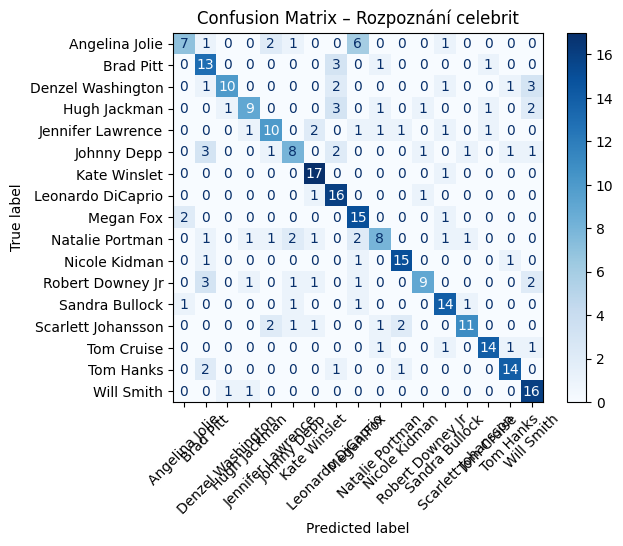

🔍 Nejvíce zaměňované celebrity:
Model si nejčastěji plete 'Angelina Jolie' s 'Megan Fox' (6 případů)

📊 Top 3 nejčastější záměny:
'Angelina Jolie' ↔ 'Megan Fox': 6 případů
'Brad Pitt' ↔ 'Leonardo DiCaprio': 3 případů
'Denzel Washington' ↔ 'Will Smith': 3 případů

📋 Přehled přesnosti a F1 skóre pro každou třídu:
                    precision    recall  f1-score   support

    Angelina Jolie       0.70      0.39      0.50        18
         Brad Pitt       0.52      0.72      0.60        18
 Denzel Washington       0.83      0.56      0.67        18
      Hugh Jackman       0.69      0.50      0.58        18
 Jennifer Lawrence       0.62      0.56      0.59        18
       Johnny Depp       0.57      0.44      0.50        18
      Kate Winslet       0.74      0.94      0.83        18
 Leonardo DiCaprio       0.59      0.89      0.71        18
         Megan Fox       0.56      0.83      0.67        18
   Natalie Portman       0.62      0.44      0.52        18
     Nicole Kidman       0

In [50]:

## 📉 Vizualizace výsledků – Confusion Matrix


from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import numpy as np
import pandas as pd

# Predikce
predictions = model.predict(X_test)
predicted_labels = np.argmax(predictions, axis=1)

# Confusion matrix
cm = confusion_matrix(y_test, predicted_labels)

# Získání názvů tříd
label_encoder = LabelEncoder()
label_encoder.fit(vyvazene_stitky)
class_names = label_encoder.classes_

# Zobrazíme matici
plt.figure(figsize=(12, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(xticks_rotation=45, cmap='Blues')
plt.title("Confusion Matrix – Rozpoznání celebrit")
plt.grid(False)
plt.show()

# Analýza nejvíce zaměňovaných tříd
cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

# Vynuluj diagonálu (správně klasifikované)
cm_wo_diag = cm.copy()
np.fill_diagonal(cm_wo_diag, 0)

most_confused = np.unravel_index(np.argmax(cm_wo_diag), cm_wo_diag.shape)
print("🔍 Nejvíce zaměňované celebrity:")
print(f"Model si nejčastěji plete '{class_names[most_confused[0]]}' s '{class_names[most_confused[1]]}' ({cm_wo_diag[most_confused]} případů)")

# TOP 3 nejčastější záměny
flat = [(i, j, cm_wo_diag[i, j]) for i in range(len(class_names)) for j in range(len(class_names)) if i != j]
flat_sorted = sorted(flat, key=lambda x: x[2], reverse=True)[:3]

print("\n📊 Top 3 nejčastější záměny:")
for i, j, count in flat_sorted:
    print(f"'{class_names[i]}' ↔ '{class_names[j]}': {count} případů")

# Přehled přesnosti a F1 skóre
print("\n📋 Přehled přesnosti a F1 skóre pro každou třídu:")
print(classification_report(y_test, predicted_labels, target_names=class_names))


Epoch 1/10
39/39 [==============================] - 21s 493ms/step - loss: 2.9151 - accuracy: 0.0981 - val_loss: 2.7326 - val_accuracy: 0.1601
Epoch 2/10
39/39 [==============================] - 20s 523ms/step - loss: 2.3752 - accuracy: 0.2698 - val_loss: 2.1312 - val_accuracy: 0.3333
Epoch 3/10
39/39 [==============================] - 19s 497ms/step - loss: 1.5870 - accuracy: 0.5372 - val_loss: 1.9641 - val_accuracy: 0.4477
Epoch 4/10
39/39 [==============================] - 20s 526ms/step - loss: 1.0571 - accuracy: 0.6909 - val_loss: 1.6358 - val_accuracy: 0.5229
Epoch 5/10
39/39 [==============================] - 20s 502ms/step - loss: 0.7417 - accuracy: 0.7809 - val_loss: 1.6470 - val_accuracy: 0.5327
Epoch 6/10
39/39 [==============================] - 21s 530ms/step - loss: 0.5078 - accuracy: 0.8577 - val_loss: 1.4998 - val_accuracy: 0.6013
Epoch 7/10
39/39 [==============================] - 19s 495ms/step - loss: 0.2913 - accuracy: 0.9264 - val_loss: 1.4961 - val_accuracy: 0.6601

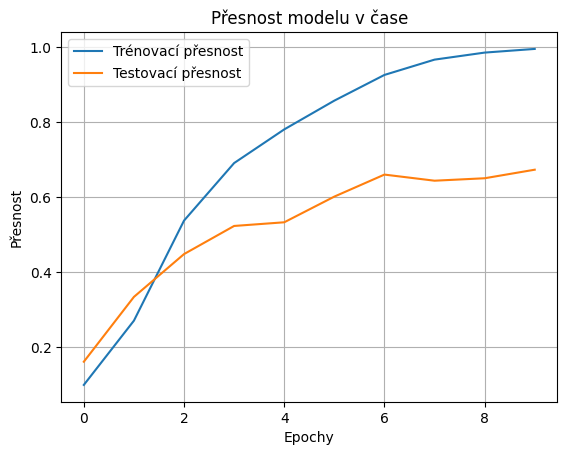

🎯 Přesnost modelu na testovacích datech: 67.32%


In [49]:
## 🧠 Trénink modelu CNN

import tensorflow as tf
from tensorflow.keras import layers, Model
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Načtení obrázků a štítků
X = np.array([np.array(Image.open(path).resize((100, 100))) / 255.0 for path in vyvazene_obrazky])
y = LabelEncoder().fit_transform(vyvazene_stitky)

# Rozdělení na trénovací a testovací data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y)

# Definice modelu
vstup = tf.keras.Input(shape=(100, 100, 3))
x = layers.Conv2D(32, (3, 3), activation='relu')(vstup)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
vystup = layers.Dense(len(np.unique(y)), activation='softmax')(x)

model = Model(inputs=vstup, outputs=vystup)

# Kompilace modelu
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Trénink
history = model.fit(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

# Výsledek
loss, acc = model.evaluate(X_test, y_test)
print(f"🎯 Přesnost na testovacích datech: {acc:.2%}")

# Uložení modelu
model.save("celebrity_face_model.h5")

# Vizualizace přesnosti
plt.plot(history.history['accuracy'], label='Trénovací přesnost')
plt.plot(history.history['val_accuracy'], label='Testovací přesnost')
plt.xlabel('Epochy')
plt.ylabel('Přesnost')
plt.legend()
plt.title("Přesnost modelu v čase")
plt.grid(True)
plt.show()

print(f"🎯 Přesnost modelu na testovacích datech: {acc:.2%}")
